## Idea process

    1. PCA and visualise

    2. Take the resulting pca and run it through tree method

    3. Using the fact that we know the redshift values of the classes, classify and visualise marking classes and outliers (this will be a yes no question)

    4. Take the ensemble of tree method and apply dbscan visualising the full picture

### Data Processing

In [1]:
# ── Stdlib ────────────────────────────────────────────────────────────────────
import os, time, random, warnings, pickle
warnings.filterwarnings("ignore")

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from umap import UMAP
from hdbscan import HDBSCAN

I0000 00:00:1788361179.049143    4667 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


KeyboardInterrupt: 

In [2]:
%matplotlib inline

In [ ]:
data = pd.read_csv("SkyObjects_FITS.csv")

In [ ]:
data.columns

Index(['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run', 'rerun', 'camcol',
       'field', 'petroRad_r', 'psfMag_r', 'modelMag_r', 'extinction_r',
       'specobjid', 'class', 'redshift', 'plate', 'mjd', 'fiberid'],
      dtype='str')

In [ ]:
useful_data = data[['u', 'g', 'r', 'i', 'z','petroRad_r', 'psfMag_r', 'modelMag_r', 'extinction_r','redshift','class']]

In [ ]:
useful_data['one_hot'],unique = pd.factorize(useful_data['class'])

In [ ]:
useful_data.columns

Index(['u', 'g', 'r', 'i', 'z', 'petroRad_r', 'psfMag_r', 'modelMag_r',
       'extinction_r', 'redshift', 'class', 'one_hot'],
      dtype='str')

In [ ]:
scaler = StandardScaler()

In [ ]:
X = useful_data[['u', 'g', 'r', 'i', 'z', 'petroRad_r', 'psfMag_r', 'modelMag_r',
       'extinction_r']].values
X_scaled = scaler.fit_transform(X)

In [ ]:
y = useful_data['class'].values

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
importances = rf.feature_importances_
feature_indexes = np.argsort(importances)[::-1][:3]

In [ ]:
X_selected = X_scaled[:, feature_indexes]

best_ari_A, best_nmi_A = None, None
best_score_A = -float('inf')
hdbscan_A = None

for min_cluster_size in [10, 20, 50, 75, 100, 200, 300, 400, 800, 1200]:

    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
    ).fit(X_selected)

    labels = clusterer.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    ari_A = adjusted_rand_score(y, labels)
    nmi_A = normalized_mutual_info_score(y, labels)

    score = (ari_A + nmi_A) / 2

    if score > best_score_A:
        best_score_A = score
        best_ari_A = ari_A
        best_nmi_A = nmi_A
        hdbscan_A = clusterer

    print(
        f"SIZE={min_cluster_size}, "
        f"clusters={n_clusters}, "
        f"ARI={ari_A:.3f}, "
        f"NMI={nmi_A:.3f}, "
        f"SCORE={score:.3f}"
    )

labels_A = hdbscan_A.labels_

SIZE=10, clusters=15, ARI=0.000, NMI=0.004, SCORE=0.002
SIZE=20, clusters=23, ARI=0.006, NMI=0.045, SCORE=0.025
SIZE=50, clusters=8, ARI=0.002, NMI=0.032, SCORE=0.017
SIZE=75, clusters=8, ARI=0.002, NMI=0.030, SCORE=0.016
SIZE=100, clusters=7, ARI=0.052, NMI=0.158, SCORE=0.105
SIZE=200, clusters=7, ARI=0.059, NMI=0.142, SCORE=0.101
SIZE=300, clusters=6, ARI=0.064, NMI=0.149, SCORE=0.106
SIZE=400, clusters=6, ARI=0.254, NMI=0.300, SCORE=0.277


In [ ]:
umapp = UMAP(n_components=3, random_state=42)
X_reduced_UMAP = umapp.fit_transform(X_scaled)

best_ari_B, best_nmi_B = None, None
best_score_B = -float('inf')
hdbscan_B= None

for min_cluster_size in [10, 20, 50, 75, 100, 200, 300, 400, 800, 1200]:

    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size,
    ).fit(X_reduced_UMAP)

    labels = clusterer.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    ari_B = adjusted_rand_score(y, labels)
    nmi_B = normalized_mutual_info_score(y, labels)

    score = (ari_B + nmi_B) / 2

    if score > best_score_B:
        best_score_B = score
        best_ari_B = ari_B
        best_nmi_B = nmi_B
        hdbscan_B = clusterer

    print(
        f"SIZE={min_cluster_size}, "
        f"clusters={n_clusters}, "
        f"ARI={ari_B:.3f}, "
        f"NMI={nmi_B:.3f}, "
        f"SCORE={score:.3f}"
    )
labels_B = hdbscan_B.labels_

In [22]:
y

<ArrowStringArray>
['GALAXY', 'GALAXY', 'GALAXY', 'GALAXY', 'GALAXY', 'GALAXY', 'GALAXY',
 'GALAXY', 'GALAXY', 'GALAXY',
 ...
    'QSO',    'QSO',    'QSO',    'QSO',    'QSO',    'QSO',    'QSO',
    'QSO',    'QSO',    'QSO']
Length: 300000, dtype: str

In [ ]:
labels_A

array([5, 5, 5, ..., 5, 5, 5], shape=(300000,))

In [ ]:
labels_B

array([6, 6, 6, ..., 6, 2, 2], shape=(300000,))

In [ ]:
print(f"Pipeline A: ARI = {best_ari_A:.3f}, NMI = {best_nmi_A:.3f}")
print(f"Pipeline B: ARI = {best_ari_B:.3f}, NMI = {best_nmi_B:.3f}")

Pipeline A: ARI = 0.002, NMI = 0.032
Pipeline B: ARI = 0.411, NMI = 0.446


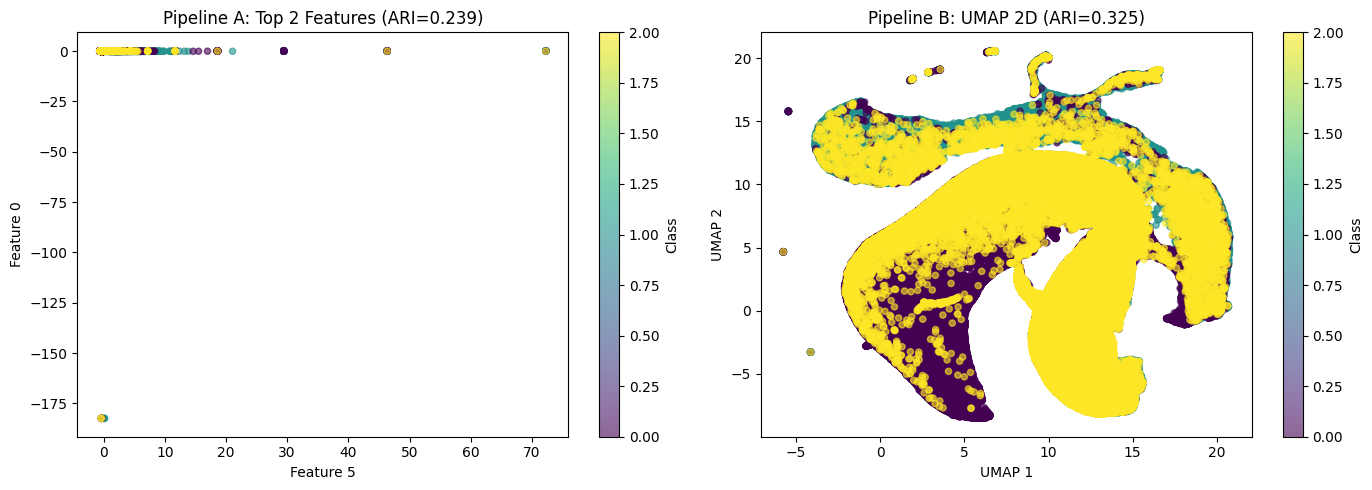

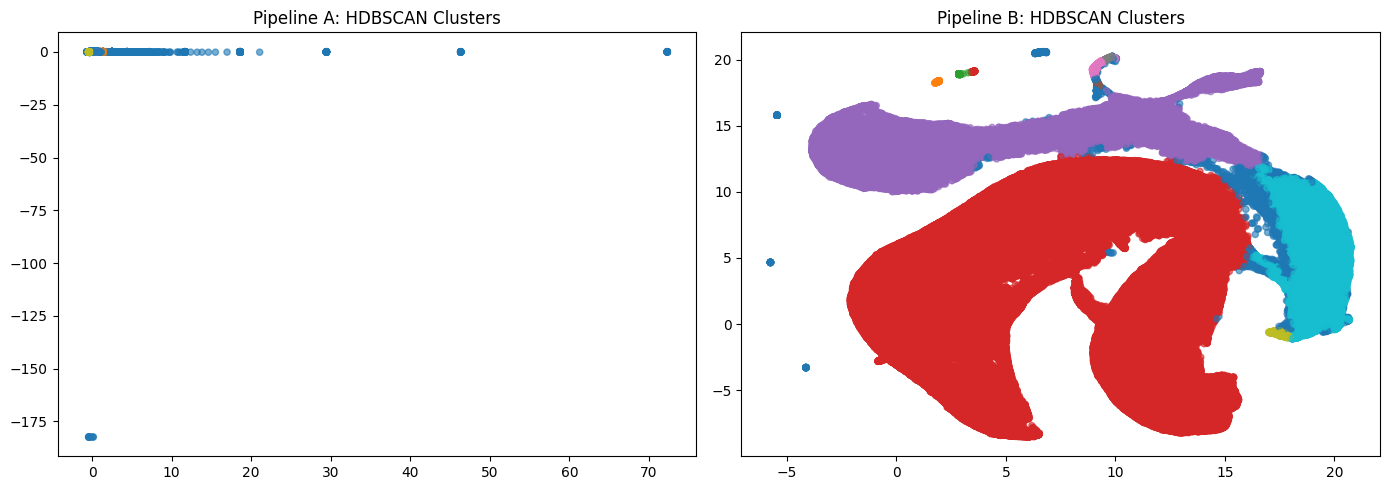

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Top 2 features, colored by true class
class_colors = {'STAR': 0, 'GALAXY': 1, 'QSO': 2}
y_numeric = np.array([class_colors[c] for c in y])
scatter_A = axes[0].scatter(X_selected[:, 0], X_selected[:, 1], c=y_numeric, cmap='viridis', alpha=0.6, s=20)
axes[0].set_title(f'Pipeline A: Top 2 Features (ARI={adjusted_rand_score(y, labels_A):.3f})')
axes[0].set_xlabel(f'Feature {feature_indexes[0]}')
axes[0].set_ylabel(f'Feature {feature_indexes[1]}')
plt.colorbar(scatter_A, ax=axes[0], label='Class')

# Plot B: UMAP, colored by true class
scatter_B = axes[1].scatter(X_reduced_UMAP[:, 0], X_reduced_UMAP[:, 1], c=y_numeric, cmap='viridis', alpha=0.6, s=20)
axes[1].set_title(f'Pipeline B: UMAP 2D (ARI={adjusted_rand_score(y, labels_B):.3f})')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
plt.colorbar(scatter_B, ax=axes[1], label='Class')

plt.tight_layout()
plt.savefig('class_separation.png', dpi=300)
plt.show()

# Optional: Show HDBSCAN cluster assignments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_selected[:, 0], X_selected[:, 1], c=labels_A, cmap='tab10', alpha=0.6, s=20)
axes[0].set_title('Pipeline A: HDBSCAN Clusters')
axes[1].scatter(X_reduced_UMAP[:, 0], X_reduced_UMAP[:, 1], c=labels_B, cmap='tab10', alpha=0.6, s=20)
axes[1].set_title('Pipeline B: HDBSCAN Clusters')
plt.tight_layout()
plt.show()

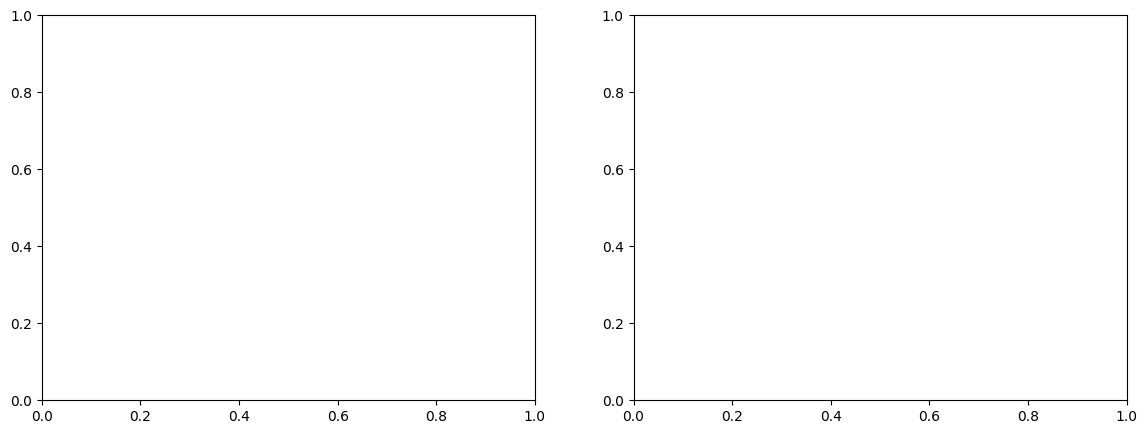

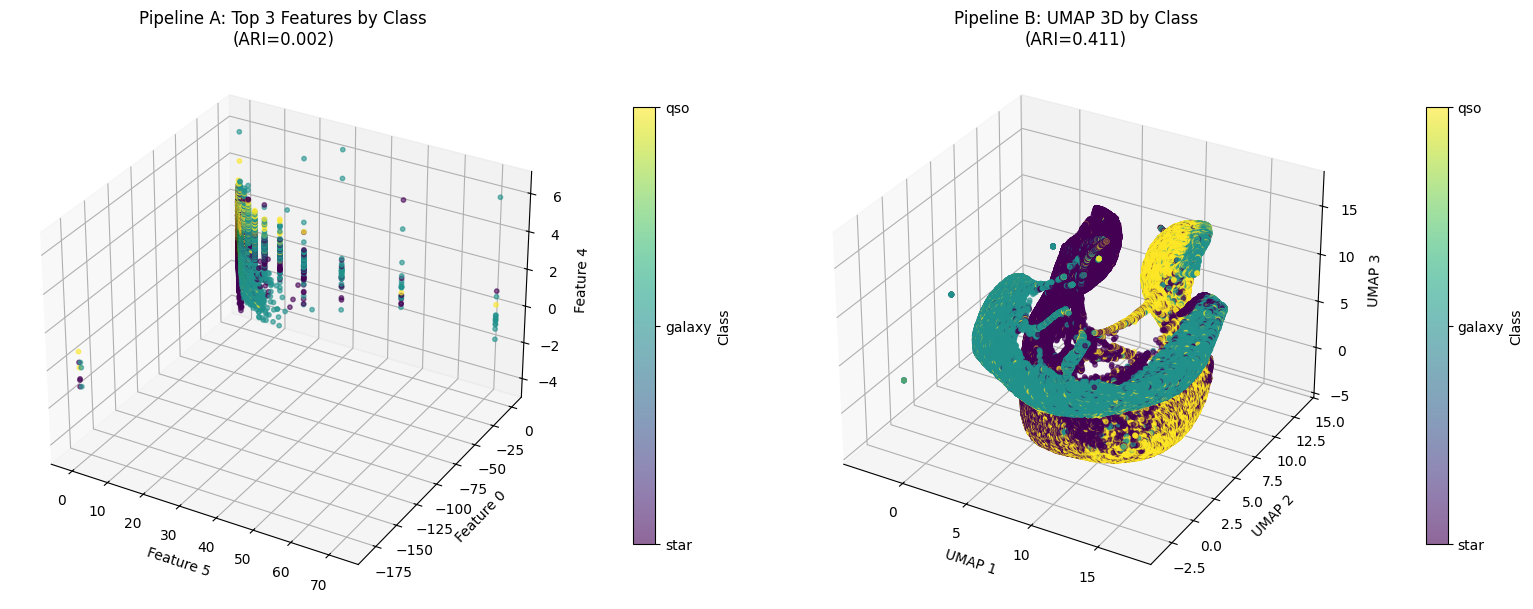

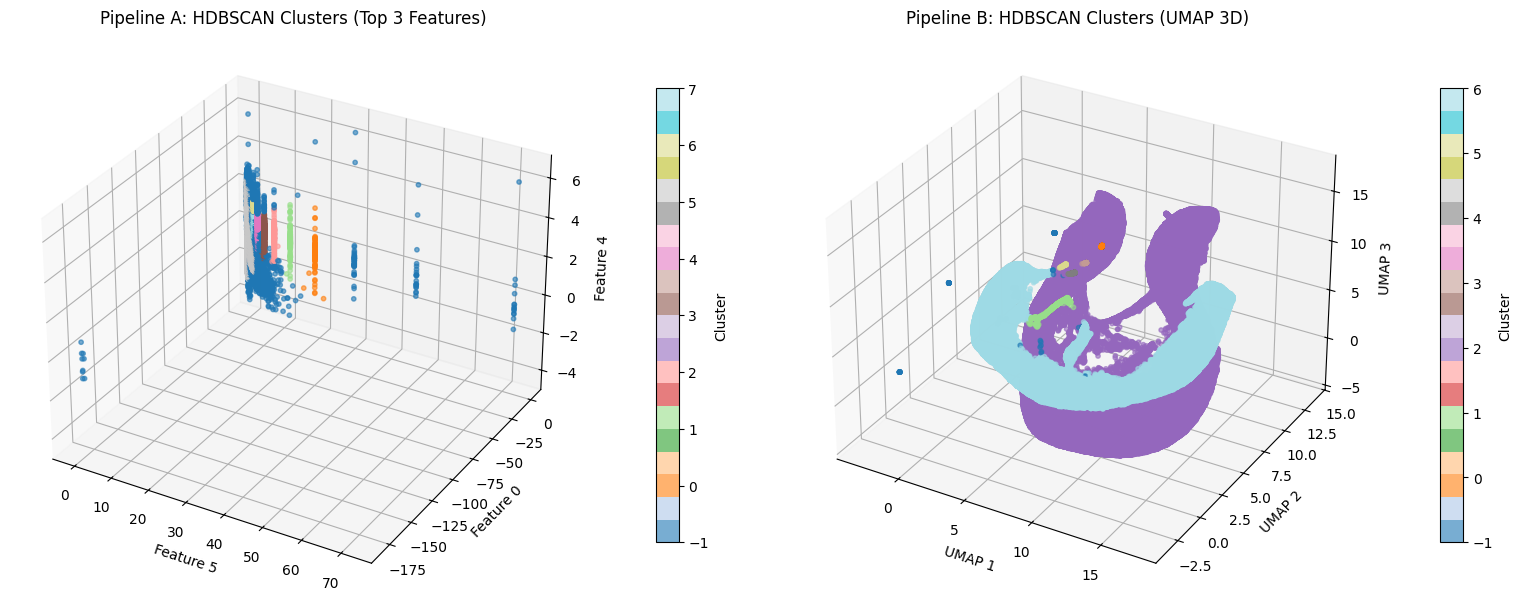

In [ ]:
# Plot A: Top 2 features, colored by true class
class_colors = {'STAR': 0, 'GALAXY': 1, 'QSO': 2}
y_numeric = np.array([class_colors[c] for c in y])

# 3D Visualization: Ground truth classes
fig = plt.figure(figsize=(16, 6))

# Pipeline A: Top 3 features colored by class
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
scatter1 = ax1.scatter(X_selected[:, 0], X_selected[:, 1], X_selected[:, 2], 
                       c=y_numeric, cmap='viridis', alpha=0.6, s=10)
ax1.set_title(f'Pipeline A: Top 3 Features by Class\n(ARI={ari_A:.3f})', fontsize=12)
ax1.set_xlabel(f'Feature {feature_indexes[0]}')
ax1.set_ylabel(f'Feature {feature_indexes[1]}')
ax1.set_zlabel(f'Feature {feature_indexes[2]}')
cbar1 = plt.colorbar(scatter1, ax=ax1, label='Class', pad=0.1, shrink=0.8)
cbar1.set_ticks([0, 1, 2])
cbar1.set_ticklabels(['star', 'galaxy', 'qso'])

# Pipeline B: UMAP colored by class
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
scatter2 = ax2.scatter(X_reduced_UMAP[:, 0], X_reduced_UMAP[:, 1], X_reduced_UMAP[:, 2], 
                       c=y_numeric, cmap='viridis', alpha=0.6, s=10)
ax2.set_title(f'Pipeline B: UMAP 3D by Class\n(ARI={ari_B:.3f})', fontsize=12)
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_zlabel('UMAP 3')
cbar2 = plt.colorbar(scatter2, ax=ax2, label='Class', pad=0.1, shrink=0.8)
cbar2.set_ticks([0, 1, 2])
cbar2.set_ticklabels(['star', 'galaxy', 'qso'])

plt.tight_layout()
plt.savefig('3d_class_separation.png', dpi=300)
plt.show()

# 3D Visualization: HDBSCAN clusters
fig = plt.figure(figsize=(16, 6))

# Pipeline A: HDBSCAN clusters
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
scatter1 = ax1.scatter(X_selected[:, 0], X_selected[:, 1], X_selected[:, 2], 
                       c=labels_A, cmap='tab20', alpha=0.6, s=10)
ax1.set_title(f'Pipeline A: HDBSCAN Clusters (Top 3 Features)', fontsize=12)
ax1.set_xlabel(f'Feature {feature_indexes[0]}')
ax1.set_ylabel(f'Feature {feature_indexes[1]}')
ax1.set_zlabel(f'Feature {feature_indexes[2]}')
plt.colorbar(scatter1, ax=ax1, label='Cluster', pad=0.1, shrink=0.8)

# Pipeline B: HDBSCAN clusters
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
scatter2 = ax2.scatter(X_reduced_UMAP[:, 0], X_reduced_UMAP[:, 1], X_reduced_UMAP[:, 2], 
                       c=labels_B, cmap='tab20', alpha=0.6, s=10)
ax2.set_title(f'Pipeline B: HDBSCAN Clusters (UMAP 3D)', fontsize=12)
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_zlabel('UMAP 3')
plt.colorbar(scatter2, ax=ax2, label='Cluster', pad=0.1, shrink=0.8)

plt.tight_layout()
plt.savefig('3d_hdbscan_clusters.png', dpi=300)
plt.show()